Using low and high pass filters to design all (possible) first and second order interfaces.
Cost is 2-norm 

In [2]:
# auto reload modules
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from globalVars import *
from load_data_pickles import *
from analysis_functions import mean_and_interquartile
from plotting_variables import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 0th order interface parameters

In [3]:
N_grid = 100
b0s = np.linspace(0.05,5,N_grid) 

G_find = b0s
zero_order_Gs = G_find
print(zero_order_Gs)

I_freq = zero(zero_order_Gs)  # discrete time domain
I_freq.shape

[0.05 0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65 0.7
 0.75 0.8  0.85 0.9  0.95 1.   1.05 1.1  1.15 1.2  1.25 1.3  1.35 1.4
 1.45 1.5  1.55 1.6  1.65 1.7  1.75 1.8  1.85 1.9  1.95 2.   2.05 2.1
 2.15 2.2  2.25 2.3  2.35 2.4  2.45 2.5  2.55 2.6  2.65 2.7  2.75 2.8
 2.85 2.9  2.95 3.   3.05 3.1  3.15 3.2  3.25 3.3  3.35 3.4  3.45 3.5
 3.55 3.6  3.65 3.7  3.75 3.8  3.85 3.9  3.95 4.   4.05 4.1  4.15 4.2
 4.25 4.3  4.35 4.4  4.45 4.5  4.55 4.6  4.65 4.7  4.75 4.8  4.85 4.9
 4.95 5.  ]


(8, 100)

## 1st order interface parameters

In [ ]:
N_grid = 100
b0s = np.linspace(0.05,5,N_grid) 
wcs = 2*np.pi*np.linspace(0.05,1,N_grid) #crossover frequency is 0.25Hz
G_find_high = []
# high pass filter: s/(s+wc)
for wc in wcs:
    for b0 in b0s:
        b1 = 0
        a0 = wc
        G_find_high.append([a0,b0,b1])
G_find_high = np.asarray(G_find_high).T
G_find_global = G_find_high
# print(G_find_global.shape)


# convert to discrete time transfer function
dt = 1./60
G_find_dis = []
for i in range(G_find_global.shape[1]):
    if np.isclose(G_find_global[1,i],G_find_global[2,i], atol=1e-14):
        pass
    else:
        a = np.array([1,G_find_global[0,i]])
        if np.isclose(G_find_global[1,i],0, atol=1e-14):
            b = np.array([G_find_global[2,i]])
        else:
            b = np.array([G_find_global[1,i],G_find_global[2,i]])
            
        num, den, dt = signal.cont2discrete((b,a),dt)
        num = num[0]
        # print(num,den)
        G_find_dis.append(np.array([den[1],num[0],num[1]])) # in discrete time domain
G_find_dis = np.asarray(G_find_dis).T
# G_find_dis.shape


# in discrete time 
# make sure the interface is stable or marginally stable
G_find_stable = []
for i in range(G_find_dis.shape[1]):
    den = np.array([1,G_find_dis[0,i]]) # 1, a0,a1
    eigenvalues = np.roots(den)
    if np.all(np.abs(eigenvalues)<=1): # stable or marginally stable
        G_find_stable.append(G_find_dis[:,i])
G_find_stable = np.asarray(G_find_stable).T
print(G_find_stable.shape) # all are stable!!

(3, 10000)


In [ ]:
# representations of Higher-Order System in discrete and continuous-time can lead to different DC gain (the discretization process may cause deviations in DC gain). 
# keep the G that makes DC gain >= 0 (when z = 1), so the game is not inverted
DCgain = np.sum(G_find_stable[1:,:],axis=0) / (1 + G_find_stable[0,:]) #numerator_value / denominator_value
G_find = G_find_stable[:,DCgain>=0]
# print(G_find.shape)

first_order_Gs = G_find
print(first_order_Gs.shape) # this is going to be different when running with different scipy versions, because of the different numerical precision when converting to discrete time transfer function.
# for the paramters we used for the experiment, we have shape (3, 8546) using scipy=1.5.0 and numpy=1.18.5, but are discontinued versions.

(3, 9149)


## 2nd order interface parameters

In [12]:
N_grid = 50
b0s = np.linspace(0.05,5,N_grid) 
# The cutoff should be below the frequency where the delay starts to introduce significant phase lag.
wcs = 2*np.pi*np.linspace(0.05,1,N_grid) #crossover frequency is 0.25Hz
zetas = np.linspace(0.5,1.5,N_grid) #Butterworth damping ratio

# high pass filter: s**2/(s**2 + 2*damp*wc*s + wc**2)
G_find_high = []
for wc in wcs:
    for zeta in zetas:
        for b0 in b0s:
            b1 = 0
            b2 = 0
            a0 = 2*wc*zeta
            a1 = wc**2
            G_find_high.append([a0, a1, b0, b1, b2])
G_find_high = np.asarray(G_find_high).T
G_find_global = G_find_high
# print(G_find_global.shape)

# convert to discrete time transfer function
dt = 1./60
G_find_dis = []
for i in range(G_find_global.shape[1]):
    a = np.array([1,G_find_global[0,i],G_find_global[1,i]])
    if np.isclose(G_find_global[2,i],0, atol=1e-14):
        if np.isclose(G_find_global[3,i],0, atol=1e-14):
            b = np.array([G_find_global[4,i]])
        else:
            b = np.array([G_find_global[3,i],G_find_global[4,i]])
    else:
        b = np.array([G_find_global[2,i],G_find_global[3,i],G_find_global[4,i]])
    num, den, dt = signal.cont2discrete((b,a),dt)
    num = num[0]
    G_find_dis.append(np.array([den[1],den[2],num[0],num[1],num[2]])) # in discrete time domain
G_find_dis = np.asarray(G_find_dis).T
# G_find_dis.shape

# in discrete time 
# make sure the interface is stable or marginally stable
G_find_stable = []
for i in range(G_find_dis.shape[1]):
    den = np.array([1,G_find_dis[0,i],G_find_dis[1,i]]) # 1, a0,a1
    eigenvalues = np.roots(den)
    if np.all(np.abs(eigenvalues)<=1): # stable or marginally stable
        G_find_stable.append(G_find_dis[:,i])
G_find_stable = np.asarray(G_find_stable).T
print(G_find_stable.shape) # all are stable!!

(5, 125000)


In [13]:
# keep the G that makes DC gain >= 0 (when z = 1), so the game is not inverted
DCgain = np.sum(G_find_stable[2:,:],axis=0) / (1 + np.sum(G_find_stable[:2,:],axis=0)) #numerator_value / denominator_value
G_find = G_find_stable[:,DCgain>=0]

second_order_Gs = G_find
print(second_order_Gs.shape)
# for the paramters we used for the experiment, we have shape (5, 87038) using scipy=1.5.0 and numpy=1.18.5, but are discontinued versions.

(5, 87102)


## baseline (passthrough)

In [146]:
# baseline performance
G_baseline = 1
loss_baseline, Y_base, UH_base, UG_base = loss_base(H_c[IX], G_baseline,lamH = lam_H,lamG = lam_I)
print('loss_baseline = ',loss_baseline)
task_performance_base = task_performance(H_c[IX], G_baseline, order = 'zero')
print('task_performance_base = ',task_performance_base)

loss_baseline =  0.09334803298450316
task_performance_base =  0.06206098441648248


## 0th order

In [147]:
# find the interface with the smallest loss
losses_0th, Y_0th, UH_0th, UG_0th = loss(H_c[IX], zero_order_Gs, order = 'zero',lamH = lam_H,lamG = lam_I)
print(losses_0th.shape)
idx_min0 = np.argmin(losses_0th)
print('idx_min = ',idx_min0)
G_star0 = zero_order_Gs[idx_min0]
print('I* 0th order = ',G_star0)
print('losses_0th = ',losses_0th[idx_min0])
G_star_freq0 = zero(G_star0)

task_performance_0th = task_performance(H_c[IX], G_star0, order = 'zero')
print('task_performance_0th = ',task_performance_0th)

(100,)
idx_min =  99
I* 0th order =  5.0
losses_0th =  0.07780652744419206
task_performance_0th =  0.018822980897289177


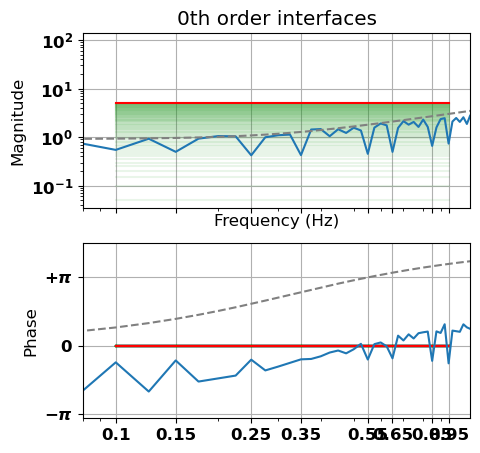

In [148]:
fig, axs = plt.subplots(2,1, figsize = (5,5),sharex = 'col', sharey = 'row')
ylimphase = (-np.pi-0.2,1.5*np.pi)
yticksphase = [-np.pi,0.,np.pi]
yticklabelsphase = [r'$-\pi$',r'$0$',r'$+\pi$']
xlim = (0,21*base_freq)
xticks = primes*0.05
xticklabels =np.round(primes*0.05,2)

I_freq = zero(zero_order_Gs)  # discrete time domain

ax = axs[0]
# for i in range(G_find_global[:,::10].shape[1]):
#     ax.plot(freqs, np.abs(I_freq_cont[:,i]), '-',color = python_colors[2], label = 'I_cont')
# ax.plot(freqs, np.abs(I_freq_cont), '-',color = python_colors[2], label = 'I_cont')
# ax.plot(freqs, np.abs(I_freq_cont_), '-',color = 'red', label = 'I_cont_')
for i in range(N_grid):
    ax.plot(freqs, np.abs(I_freq[:,i]), '-',color = python_colors[2], label = 'I', alpha = 0.1)
# for i in range(G_find_stable[:,::10].shape[1]):
#     ax.plot(freqs, np.abs(I_freq_[:,i]), '-',color = python_colors[2], label = 'I', alpha = 0.1)
# ax.plot(freqs, np.abs(H_c[IX]*I_freq[:,i]), '-',color = 'red', label = 'HI', alpha = 0.1)
ax.plot(freqs, np.abs(G_star_freq0),color = 'red')
ax.plot(xf, np.abs(H_c[:N//2]), color = python_colors[0],label = 'H (delayed)') # H when interface is 1 (passthough)
# ax.fill_between(xf, np.abs(H_upper_gain_c[:N//2]), np.abs(H_lower_gain_c[:N//2]), color = python_colors[0], alpha = 0.5)
ax.plot(xf, np.abs(1/M_c[:N//2]), '--',color = 'grey',label = r'$M^{-1}$')
ax.set_ylabel('Magnitude')
ax.set_xlabel('Frequency (Hz)')
ax.set_xlim(0.08,1.1)
# ax.set_ylim(0.01,100)
ax.set_xscale("log")
ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels,rotation=45)
ax.grid('on',zorder=-1)
ax.set_yscale("log")


ax = axs[1]
# for i in range(G_find_global[:,::10].shape[1]):
#     ax.plot(freqs, np.angle(I_freq_cont[:,i]), '-',color = python_colors[2], label = 'I_cont')
# ax.plot(freqs, np.angle(I_freq_cont), color = python_colors[2], label = 'I')
# ax.plot(freqs, np.angle(I_freq_cont_), color = 'red', label = 'I')
for i in range(N_grid): 
    ax.plot(freqs, np.angle(I_freq[:,i]), '-',color = python_colors[2], label = 'I', alpha = 0.1)
# for i in range(G_find_stable[:,::10].shape[1]):
#     ax.plot(freqs, np.angle(I_freq_[:,i]), '-',color = python_colors[2], label = 'I', alpha = 0.1)
ax.plot(freqs, np.angle(G_star_freq0),color = 'red')
ax.plot(xf, np.angle(H_c[:N//2]), color = python_colors[0], label = 'H (delayed)')
# ax.fill_between(xf, np.angle(H_upper_tau_c[:N//2]), np.angle(H_lower_tau_c[:N//2]), color = python_colors[0], alpha = 0.5)
M_angles = np.zeros((N//2)) # fix circular phase
for i in range(N//2):
    M_angle = np.angle(1/M_c[i])
    if M_angle >= 0:
        M_angles[i] = M_angle
    else:
        M_angles[i] = M_angle+2*np.pi
ax.plot(xf, M_angles, '--',color = 'grey',label = r'$M^{-1}$')
# fixed_circular = np.angle(np.exp(1j*np.angle(1/M_c[:N//2])+ np.pi/2)) -np.pi/2
# ax.plot(xf, np.angle(1/M_c[:N//2]), '--',color = 'grey',label = r'$M^{-1}$')
ax.set_ylabel('Phase') 
ax.grid('on',zorder=-1)
ax.set_ylim(ylimphase)
ax.set_yticks(yticksphase)
ax.set_yticklabels(yticklabelsphase)
# axs[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
axs[0].set_title('0th order interfaces')
plt.show()

## 1st order

In [149]:
# first order 
# G_find = first_order_Gs

# find the interface with the smallest loss
losses_1st, Y_1st, UH_1st, UG_1st = loss(H_c[IX], first_order_Gs, order = 'first',lamH = lam_H,lamG = lam_I)
print(losses_1st.shape)
idx_min1 = np.argmin(losses_1st)
print('idx_min = ',idx_min1)
G_star1 = first_order_Gs[:,idx_min1]
print('losses_1st = ',losses_1st[idx_min1])
print('I* 1st order = ',G_star1)
G_star_freq1 = first(G_star1)

task_performance_1st = task_performance(H_c[IX], G_star1, order = 'first')
print('task_performance_1st = ',task_performance_1st)

(8546,)
idx_min =  1536
losses_1st =  0.06464182490105101
I* 1st order =  [-0.97694596  1.55       -1.55      ]
task_performance_1st =  0.04313791847515389


In [150]:
# I_freq = first(G_find)  # discrete time domain
I_freq = first(first_order_Gs[:,::10])  # discrete time domain
I_freq.shape

(8, 855)

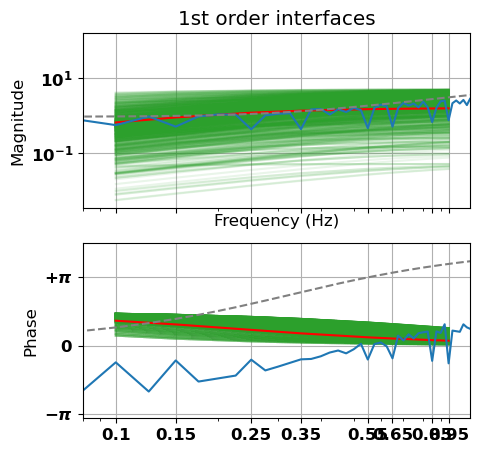

In [151]:
fig, axs = plt.subplots(2,1, figsize = (5,5),sharex = 'col', sharey = 'row')
ylimphase = (-np.pi-0.2,1.5*np.pi)
yticksphase = [-np.pi,0.,np.pi]
yticklabelsphase = [r'$-\pi$',r'$0$',r'$+\pi$']
xlim = (0,21*base_freq)
xticks = primes*0.05
xticklabels =np.round(primes*0.05,2)

ax = axs[0]
# for i in range(G_find_global[:,::10].shape[1]):
#     ax.plot(freqs, np.abs(I_freq_cont[:,i]), '-',color = python_colors[2], label = 'I_cont')
# ax.plot(freqs, np.abs(I_freq_cont), '-',color = python_colors[2], label = 'I_cont')
# ax.plot(freqs, np.abs(I_freq_cont_), '-',color = 'red', label = 'I_cont_')
for i in range(first_order_Gs[:,::10].shape[1]):
    ax.plot(freqs, np.abs(I_freq[:,i]), '-',color = python_colors[2], label = 'I', alpha = 0.1)
ax.plot(freqs, np.abs(G_star_freq1),color = 'red')
# for i in range(G_find_stable[:,::10].shape[1]):
#     ax.plot(freqs, np.abs(I_freq_[:,i]), '-',color = python_colors[2], label = 'I', alpha = 0.1)
# ax.plot(freqs, np.abs(H_c[IX]*I_freq[:,i]), '-',color = 'red', label = 'HI', alpha = 0.1)
ax.plot(xf, np.abs(H_c[:N//2]), color = python_colors[0],label = 'H (delayed)') # H when interface is 1 (passthough)
# ax.fill_between(xf, np.abs(H_upper_gain_c[:N//2]), np.abs(H_lower_gain_c[:N//2]), color = python_colors[0], alpha = 0.5)
ax.plot(xf, np.abs(1/M_c[:N//2]), '--',color = 'grey',label = r'$M^{-1}$')
ax.set_ylabel('Magnitude')
ax.set_xlabel('Frequency (Hz)')
ax.set_xlim(0.08,1.1)
# ax.set_ylim(0.01,100)
ax.set_xscale("log")
ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels,rotation=45)
ax.grid('on',zorder=-1)
ax.set_yscale("log")


ax = axs[1]
# for i in range(G_find_global[:,::10].shape[1]):
#     ax.plot(freqs, np.angle(I_freq_cont[:,i]), '-',color = python_colors[2], label = 'I_cont')
# ax.plot(freqs, np.angle(I_freq_cont), color = python_colors[2], label = 'I')
# ax.plot(freqs, np.angle(I_freq_cont_), color = 'red', label = 'I')
for i in range(first_order_Gs[:,::10].shape[1]): 
    ax.plot(freqs, np.angle(I_freq[:,i]), '-',color = python_colors[2], label = 'I', alpha = 0.1)
ax.plot(freqs, np.angle(G_star_freq1),color = 'red')
# for i in range(G_find_stable[:,::10].shape[1]):
#     ax.plot(freqs, np.angle(I_freq_[:,i]), '-',color = python_colors[2], label = 'I', alpha = 0.1)
ax.plot(xf, np.angle(H_c[:N//2]), color = python_colors[0], label = 'H (delayed)')
# ax.fill_between(xf, np.angle(H_upper_tau_c[:N//2]), np.angle(H_lower_tau_c[:N//2]), color = python_colors[0], alpha = 0.5)
M_angles = np.zeros((N//2)) # fix circular phase
for i in range(N//2):
    M_angle = np.angle(1/M_c[i])
    if M_angle >= 0:
        M_angles[i] = M_angle
    else:
        M_angles[i] = M_angle+2*np.pi
ax.plot(xf, M_angles, '--',color = 'grey',label = r'$M^{-1}$')
# fixed_circular = np.angle(np.exp(1j*np.angle(1/M_c[:N//2])+ np.pi/2)) -np.pi/2
# ax.plot(xf, np.angle(1/M_c[:N//2]), '--',color = 'grey',label = r'$M^{-1}$')
ax.set_ylabel('Phase') 
ax.grid('on',zorder=-1)
ax.set_ylim(ylimphase)
ax.set_yticks(yticksphase)
ax.set_yticklabels(yticklabelsphase)
# axs[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
axs[0].set_title('1st order interfaces')
plt.show()

## 2nd order

In [152]:
# find the interface with the smallest loss
losses_2nd, Y_2nd, UH_2nd, UG_2nd = loss(H_c[IX], second_order_Gs, order = 'second',lamH = lam_H,lamG = lam_I)
print(losses_2nd.shape)
idx_min2 = np.argmin(losses_2nd)
print('idx_min = ',idx_min2)
G_star2 = second_order_Gs[:,idx_min2]
print('losses_2nd = ',losses_2nd[idx_min2])
print('I* 2nd order = ',G_star2)
G_star_freq2 = second(G_star2)

task_performance_2nd = task_performance(H_c[IX], G_star2, order = 'second')
print('task_performance_2nd = ',task_performance_2nd)

(87038,)
idx_min =  5277
losses_2nd =  0.05653196388860211
I* 2nd order =  [-1.9886095   0.98873708  1.06020408 -2.12034041  1.06013633]
task_performance_2nd =  0.03739297325521805


In [153]:
# I_freq = second(G_find)  # discrete time domain
I_freq = second(second_order_Gs[:,::10])  # discrete time domain
# I_freq = second(G_find[:,::1000])  # discrete time domain
I_freq.shape

(8, 8704)

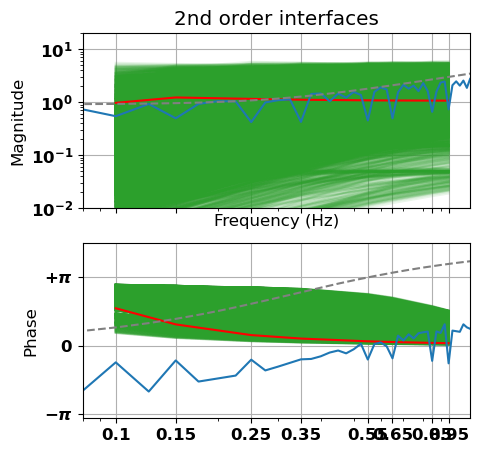

In [154]:
fig, axs = plt.subplots(2,1, figsize = (5,5),sharex = 'col', sharey = 'row')
ylimphase = (-np.pi-0.2,1.5*np.pi)
yticksphase = [-np.pi,0.,np.pi]
yticklabelsphase = [r'$-\pi$',r'$0$',r'$+\pi$']
xlim = (0,21*base_freq)
xticks = primes*0.05
xticklabels =np.round(primes*0.05,2)

ax = axs[0]
# ax.plot(freqs, np.abs(I_freq_cont), '-',color = python_colors[2], label = 'I_cont')
# ax.plot(freqs, np.abs(I_freq_cont_), '-',color = 'red', label = 'I_cont_')
for i in range(second_order_Gs[:,::10].shape[1]):
    ax.plot(freqs, np.abs(I_freq[:,i]), '-',color = python_colors[2], label = 'I', alpha = 0.1)
# ax.plot(freqs, np.abs(H_c[IX]*I_freq[:,i]), '-',color = 'red', label = 'HI', alpha = 0.1)
ax.plot(freqs, np.abs(G_star_freq2),color = 'red')
ax.plot(xf, np.abs(H_c[:N//2]), color = python_colors[0],label = 'H (delayed)') # H when interface is 1 (passthough)
# ax.fill_between(xf, np.abs(H_upper_gain_c[:N//2]), np.abs(H_lower_gain_c[:N//2]), color = python_colors[0], alpha = 0.5)
ax.plot(xf, np.abs(1/M_c[:N//2]), '--',color = 'grey',label = r'$M^{-1}$')
ax.set_ylabel('Magnitude')
ax.set_xlabel('Frequency (Hz)')
ax.set_xlim(0.08,1.1)
ax.set_ylim(0.01,20)
ax.set_xscale("log")
ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels,rotation=45)
ax.grid('on',zorder=-1)
ax.set_yscale("log")


ax = axs[1]
# ax.plot(freqs, np.angle(I_freq_cont), color = python_colors[2], label = 'I')
# ax.plot(freqs, np.angle(I_freq_cont_), color = 'red', label = 'I')
for i in range(second_order_Gs[:,::10].shape[1]): 
    ax.plot(freqs, np.angle(I_freq[:,i]), '-',color = python_colors[2], label = 'I', alpha = 0.1)
ax.plot(freqs, np.angle(G_star_freq2),color = 'red')
ax.plot(xf, np.angle(H_c[:N//2]), color = python_colors[0], label = 'H (delayed)')
# ax.fill_between(xf, np.angle(H_upper_tau_c[:N//2]), np.angle(H_lower_tau_c[:N//2]), color = python_colors[0], alpha = 0.5)
M_angles = np.zeros((N//2)) # fix circular phase
for i in range(N//2):
    M_angle = np.angle(1/M_c[i])
    if M_angle >= 0:
        M_angles[i] = M_angle
    else:
        M_angles[i] = M_angle+2*np.pi
ax.plot(xf, M_angles, '--',color = 'grey',label = r'$M^{-1}$')
# fixed_circular = np.angle(np.exp(1j*np.angle(1/M_c[:N//2])+ np.pi/2)) -np.pi/2
# ax.plot(xf, np.angle(1/M_c[:N//2]), '--',color = 'grey',label = r'$M^{-1}$')
ax.set_ylabel('Phase') 
ax.grid('on',zorder=-1)
ax.set_ylim(ylimphase)
ax.set_yticks(yticksphase)
ax.set_yticklabels(yticklabelsphase)
# axs[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
axs[0].set_title('2nd order interfaces')
plt.show()

# compare conditions

In [155]:
print('task performance for 0th = ', task_performance_0th)
print('task performance for 1st = ', task_performance_1st)
print('task performance for 2nd = ', task_performance_2nd)
print('\n')
print('task performance for base = ', task_performance_base)
print('\n')
print('loss for 0th = ', losses_0th[idx_min0])
print('loss for 1st = ', losses_1st[idx_min1])
print('loss for 2nd = ', losses_2nd[idx_min2])
print('\n')
print('loss for base = ', loss_baseline)

task performance for 0th =  0.018822980897289177
task performance for 1st =  0.04313791847515389
task performance for 2nd =  0.03739297325521805


task performance for base =  0.06206098441648248


loss for 0th =  0.07780652744419206
loss for 1st =  0.06464182490105101
loss for 2nd =  0.05653196388860211


loss for base =  0.09334803298450316


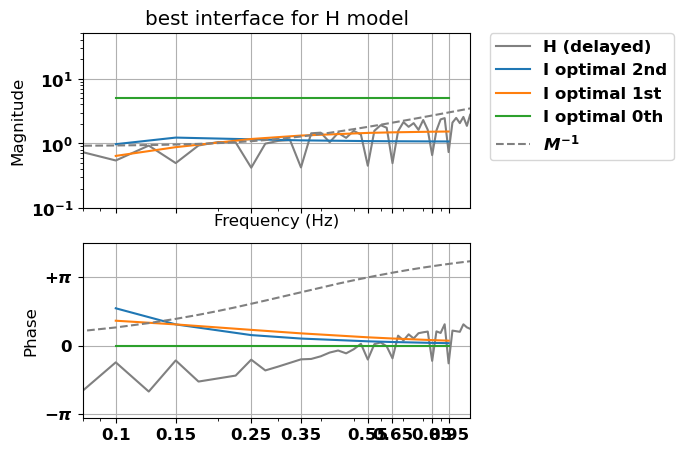

In [156]:
# plot the best interface for this H model
fig, axs = plt.subplots(2,1, figsize = (5,5),sharex = 'col', sharey = 'row')
ylimphase = (-np.pi-0.2,1.5*np.pi)
yticksphase = [-np.pi,0.,np.pi]
yticklabelsphase = [r'$-\pi$',r'$0$',r'$+\pi$']
xlim = (0,21*base_freq)
xticks = primes*0.05
xticklabels =np.round(primes*0.05,2)

ax = axs[0]
ax.plot(xf, np.abs(H_c[:N//2]), color = 'grey',label = 'H (delayed)') # H when interface is 1 (passthough)
# ax.fill_between(xf, np.abs(H_upper_gain_c[:N//2]), np.abs(H_lower_gain_c[:N//2]), color = 'grey', alpha = 0.5)
ax.plot(freqs, np.abs(G_star_freq2), color = python_colors[0], label = 'I optimal 2nd')
ax.plot(freqs, np.abs(G_star_freq1), color = python_colors[1], label = 'I optimal 1st')
ax.plot(freqs, np.abs(G_star_freq0), color = python_colors[2], label = 'I optimal 0th')
ax.plot(xf, np.abs(1/M_c[:N//2]), '--',color = 'grey',label = r'$M^{-1}$')
ax.set_ylabel('Magnitude')
ax.set_xlabel('Frequency (Hz)')
ax.set_xlim(0.08,1.1)
ax.set_ylim(0.1,50)
ax.set_xscale("log")
ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels,rotation=45)
ax.grid('on',zorder=-1)
ax.set_yscale("log")


ax = axs[1]
ax.plot(xf, np.angle(H_c[:N//2]), color = 'grey', label = 'H (delayed)')
# ax.fill_between(xf, np.angle(H_upper_tau_c[:N//2]), np.angle(H_lower_tau_c[:N//2]), color = 'grey', alpha = 0.5)
ax.plot(freqs, np.angle(G_star_freq2), color = python_colors[0], label = 'I optimal 2nd')
ax.plot(freqs, np.angle(G_star_freq1), color = python_colors[1], label = 'I optimal 1st')
ax.plot(freqs, np.angle(G_star_freq0), color = python_colors[2], label = 'I optimal 0th')
M_angles = np.zeros((N//2)) # fix circular phase
for i in range(N//2):
    if np.angle(1/M_c[i]) >= 0:
        M_angles[i] = np.angle(1/M_c[i])
    else:
        M_angles[i] = np.angle(1/M_c[i])+2*np.pi
ax.plot(xf, M_angles, '--',color = 'grey',label = r'$M^{-1}$')
# fixed_circular = np.angle(np.exp(1j*np.angle(1/M_c[:N//2])+ np.pi/2)) -np.pi/2
# ax.plot(xf, np.angle(1/M_c[:N//2]), '--',color = 'grey',label = r'$M^{-1}$')
ax.set_ylabel('Phase') 
ax.grid('on',zorder=-1)
ax.set_ylim(ylimphase)
ax.set_yticks(yticksphase)
ax.set_yticklabels(yticklabelsphase)
axs[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
axs[0].set_title('best interface for H model')
plt.show()

In [157]:
Y_2nd_star = Y_2nd[:,idx_min2]
Y_1st_star  = Y_1st[:,idx_min1]
Y_0th_star  = Y_0th[:,idx_min0]

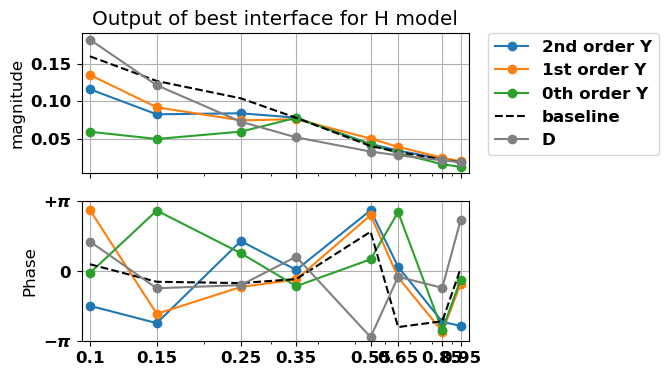

In [158]:
# Y freq domain responses in the last few trials, compare to D
xticks = np.array([0.1 , 0.15, 0.25, 0.35, 0.55, 0.65, 0.85, 0.95])
xlim = (0.095, 1.0)
ylimphase = (-np.pi,np.pi)
yticksphase = [-np.pi,0.,np.pi]
yticklabelsphase = [r'$-\pi$',r'$0$',r'$+\pi$']

D = polar2rec(amps) # D = disturbance (freq) at stim freqs

fig,axs = plt.subplots(2,1,sharex=True,figsize=(5,4))
ax = axs[0]
ax.plot(freqs, abs(Y_2nd_star),'-o',label = '2nd order Y')
ax.plot(freqs, abs(Y_1st_star),'-o',label = '1st order Y')
ax.plot(freqs, abs(Y_0th_star),'-o',label = '0th order Y')
ax.plot(freqs, abs(Y_base),'--',color = 'black',label = 'baseline')
ax.plot(freqs, abs(D),'-o',color = 'grey',label = 'D')
ax.set_xscale("log")
ax.set_xlim(xlim)
ax.set_xticks(xticks)
ax.set_xticklabels(xticks,rotation=90) 
ax.grid('on',zorder=-1)
ax.set_ylabel('magnitude')
ax.set_title('Output of best interface for H model')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

ax = axs[1]
ax.plot(freqs, np.angle(Y_2nd_star),'-o',label = '2nd order Y')
ax.plot(freqs, np.angle(Y_1st_star),'-o',label = '1st order Y')
ax.plot(freqs, np.angle(Y_0th_star),'-o',label = '0th order Y')
ax.plot(freqs, np.angle(Y_base),'--',color = 'black',label = 'baseline')
ax.plot(freqs, np.angle(D),'-o',color = 'grey',label = 'D')
ax.set_ylabel('Phase') 
ax.grid('on',zorder=-1)
ax.set_ylim(ylimphase)
ax.set_yticks(yticksphase)
ax.set_yticklabels(yticklabelsphase)
# ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.show()

These are the zero_order_Gs, first_order_Gs, second_order_Gs saved in global_search_interfaces_2norm_cost.pkl

# save pickles

In [159]:
# Save the array to a file
DATA_PATH = 'C:\\Users\\amber\\Documents\\GitHub\\hil-game' #change this for your computer

Gs = [G_star0, G_star1, G_star2, zero_order_Gs, first_order_Gs, second_order_Gs]
with open(DATA_PATH + '\\protocols\\global_search_interfaces_2norm_cost.pkl', 'wb') as file:
    pickle.dump(Gs, file)

In [160]:
zero_order_Gs.shape, first_order_Gs.shape, second_order_Gs.shape

((100,), (3, 8546), (5, 87038))